# Titanic dataset — Comprehensive EDA & Preprocessing

**TL;DR:** This notebook loads Seaborn's `titanic` dataset and demonstrates common EDA and preprocessing tasks:

- exploratory data analysis & visualization
- handling missing data (drop, mean/median, KNN, MICE)
- outlier detection & handling (Z-score, IQR, capping)
- data transformation (log, Box-Cox where appropriate)
- encoding categorical variables (one-hot, label)
- feature engineering and selection
- feature scaling: normalization, standardization, robust scaling
- correlation & covariance analysis

Run cells sequentially. Each section contains explanations and code examples.


In [1]:
# Imports & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor

# load seaborn dataset
df = sns.load_dataset('titanic')
df_original = df.copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Basic EDA

- `df.info()` / `df.describe()`
- Missing values overview
- Quick visual checks


In [2]:
# Basic checks
print('Shape:', df.shape)
display(df.info())
display(df.describe(include='all').T)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
pd.concat([missing, missing_pct.rename('pct')], axis=1).head(20)

Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,0,pct
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


## Data Visualization (Matplotlib & Seaborn)

- Numerical distributions, categorical counts
- Boxplots & Violin plots to inspect spread and outliers


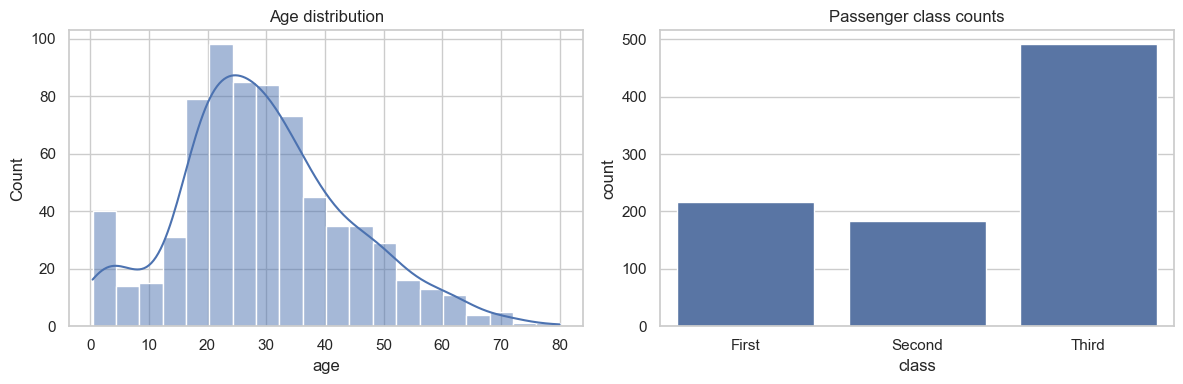

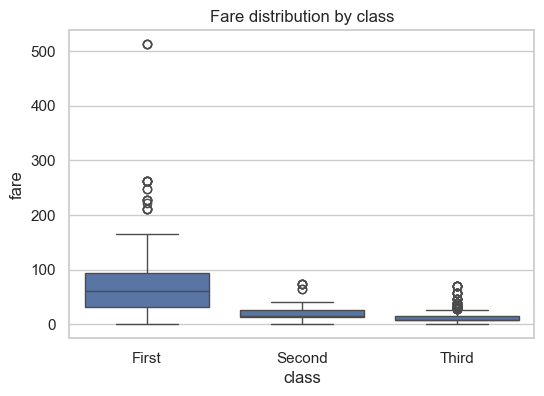

In [3]:
# Numeric distributions and counts
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Age distribution')

plt.subplot(1,2,2)
sns.countplot(data=df, x='class')
plt.title('Passenger class counts')
plt.tight_layout()
plt.show()

# Boxplot: fare by class
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='class', y='fare')
plt.title('Fare distribution by class')
plt.show()

## Advanced Visualizations with Seaborn

- Pairplot, heatmap for correlations, jointplot


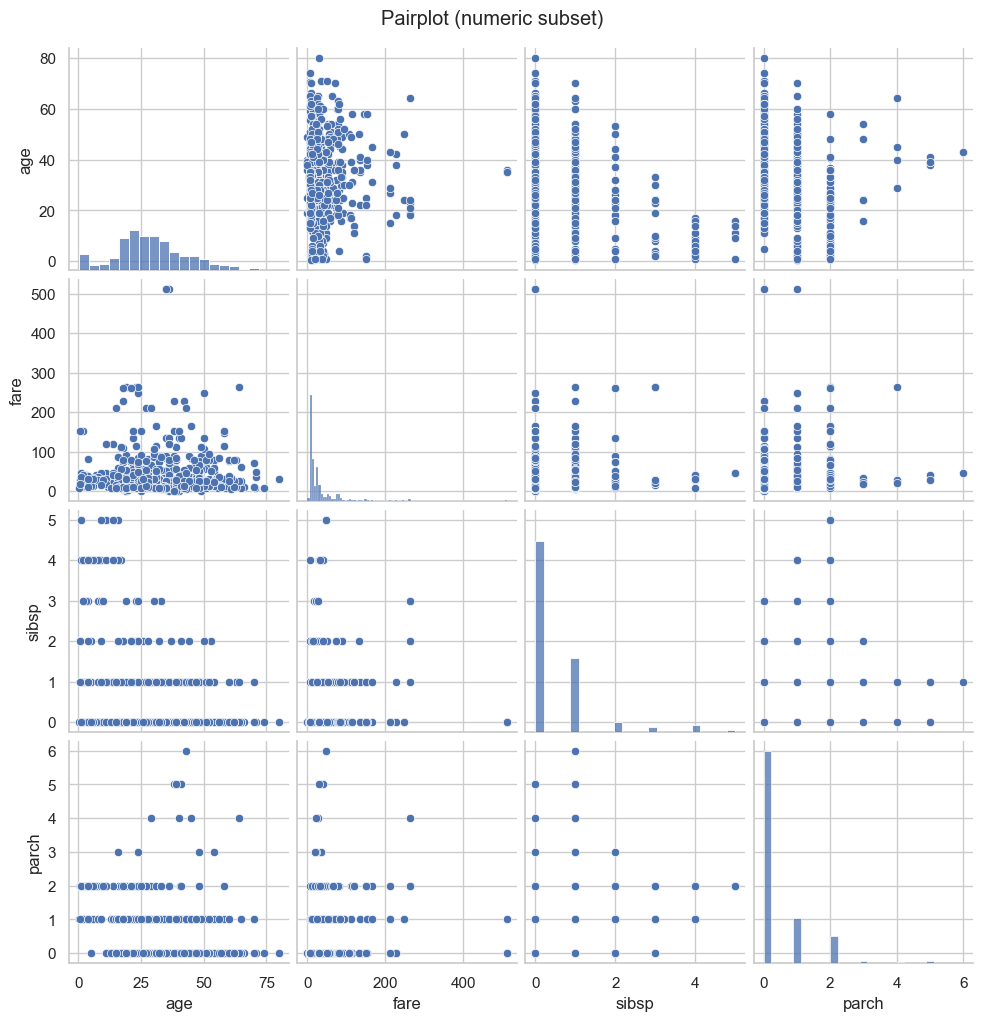

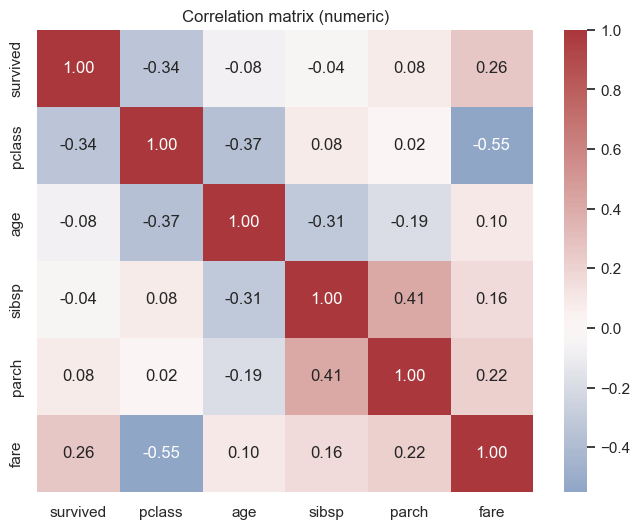

In [4]:
# Pairplot (subset to avoid crowding)
sns.pairplot(df.dropna(subset=['age','fare'])[['age','fare','sibsp','parch']])
plt.suptitle('Pairplot (numeric subset)', y=1.02)
plt.show()

# Correlation heatmap for numeric columns
num = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation matrix (numeric)')
plt.show()

## Summary Statistics, Correlation & Covariance

In [5]:
# Summary statistics already shown. Here: correlation and covariance examples
corr = num.corr()
cov = num.cov()
display(corr)
display(cov)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


,survived,pclass,age,sibsp,parch,fare
survived,0.236772,-0.137703,-0.551296,-0.018954,0.032017,6.221787
pclass,-0.137703,0.699015,-4.496004,0.076599,0.012429,-22.830196
age,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,73.849030
sibsp,-0.018954,0.076599,-4.163334,1.216043,0.368739,8.748734
parch,0.032017,0.012429,-2.344191,0.368739,0.649728,8.661052
fare,6.221787,-22.830196,73.849030,8.748734,8.661052,2469.436846


## Managing Missing Data

Strategies shown:
- Removal (drop)
- Simple imputation (mean/median/mode)
- KNN Imputation
- MICE / Iterative Imputer


In [6]:
# Columns with noticeable missing values
df.isnull().mean().sort_values(ascending=False).head(20)

deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
sex            0.000000
pclass         0.000000
survived       0.000000
fare           0.000000
parch          0.000000
sibsp          0.000000
class          0.000000
adult_male     0.000000
who            0.000000
alive          0.000000
alone          0.000000
dtype: float64

In [7]:
# 1) Removal: drop rows with missing target or many missing
df_drop = df.dropna(subset=['fare','age'])  # example of selective dropping
print('After drop shape:', df_drop.shape)

After drop shape: (714, 15)


In [8]:
# 2) Simple imputation (mean/median for numeric, mode for categorical)
df_simple = df.copy()
df_simple['age_mean_impute'] = df_simple['age'].fillna(df_simple['age'].mean())
df_simple['embarked_mode_impute'] = df_simple['embarked'].fillna(df_simple['embarked'].mode()[0])
df_simple[['age','age_mean_impute','embarked','embarked_mode_impute']].head()

,age,age_mean_impute,embarked,embarked_mode_impute
0,22.0,22.0,S,S
1,38.0,38.0,C,C
2,26.0,26.0,S,S
3,35.0,35.0,S,S
4,35.0,35.0,S,S


In [9]:
# 3) KNN Imputation (numeric columns only)
knn_df = df.copy()
numeric_cols = knn_df.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5)
knn_df[numeric_cols] = imputer.fit_transform(knn_df[numeric_cols])
knn_df[numeric_cols].isnull().sum()

survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

In [10]:
# 4) MICE / IterativeImputer (works across numeric columns; categorical should be encoded first)
mice_df = df.copy()
# Encode simple ordinal mapping for sex and embark temporarily for imputer (so iterative imputer can use them)
mice_df_enc = mice_df.copy()
mice_df_enc['sex_enc'] = mice_df_enc['sex'].map({'male':0,'female':1})
mice_df_enc['embarked_enc'] = mice_df_enc['embarked'].map({'S':0,'C':1,'Q':2})
imp = IterativeImputer(random_state=0, max_iter=10)
cols_for_imp = ['age','fare','sibsp','parch','sex_enc','embarked_enc']
mice_df_enc[cols_for_imp] = imp.fit_transform(mice_df_enc[cols_for_imp])
mice_df_enc[['age','fare','sex_enc','embarked_enc']].head()

,age,fare,sex_enc,embarked_enc
0,22.0,7.2500,0.0,0.0
1,38.0,71.2833,1.0,1.0
2,26.0,7.9250,1.0,0.0
3,35.0,53.1000,1.0,0.0
4,35.0,8.0500,0.0,0.0


## Handling Outliers & Outlier Detection

Methods:
- Z-score
- IQR
- LOF (Local Outlier Factor)
- Capping / flooring


In [11]:
from scipy import stats

# Z-score method
age_z = df['age'].dropna()
z_scores = stats.zscore(age_z)
outliers_z = age_z[np.abs(z_scores) > 3]
print('Z-score detected outliers (age):', outliers_z.shape[0])

# IQR method for fare
fare = df['fare'].dropna()
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = fare[(fare < lower) | (fare > upper)]
print('IQR detected outliers (fare):', outliers_iqr.shape[0])

# LOF (multivariate outlier detection)
lof_cols = ['age','fare','sibsp','parch']
lof_df = df[lof_cols].dropna()
lof = LocalOutlierFactor(n_neighbors=20)
y_pred = lof.fit_predict(lof_df)
lof_outliers = lof_df[y_pred == -1]
print('LOF detected outliers:', lof_outliers.shape[0])

# Capping (winsorizing) example for fare
df_capped = df.copy()
df_capped['fare_capped'] = df_capped['fare'].clip(lower=lower, upper=upper)
df[['fare','fare_capped']].head()

Z-score detected outliers (age): 2
IQR detected outliers (fare): 116
LOF detected outliers: 24


KeyError: "['fare_capped'] not in index"

## Feature Engineering

- Create `family_size`, `is_alone`, extract title from name, etc.

In [ ]:
# Family size and is_alone
fe_df = df.copy()
fe_df['family_size'] = fe_df['sibsp'] + fe_df['parch'] + 1
fe_df['is_alone'] = (fe_df['family_size'] == 1).astype(int)

# Extract title from name (where available)
def extract_title(name):
    if pd.isnull(name): return np.nan
    if ',' in name and '.' in name:
        return name.split(',')[1].split('.')[0].strip()
    return np.nan

# Seaborn's titanic dataset may have name NaNs depending version; guard accordingly
if 'who' not in fe_df.columns and 'name' in fe_df.columns:
    fe_df['title'] = fe_df['name'].apply(extract_title)
else:
    # create a simple title relation based on sex & age as placeholder
    fe_df['title'] = np.where(fe_df['sex']=='male','Mr','Ms')

fe_df[['sibsp','parch','family_size','is_alone','title']].head()

## Encoding Categorical Variables

- One-hot (pd.get_dummies)
- Label encoding for ordinal-like features


In [ ]:
enc_df = fe_df.copy()
# One-hot encode 'embarked' and 'class'
enc_df = pd.get_dummies(enc_df, columns=['embarked','class'], drop_first=True)

# Label encode 'sex'
le = LabelEncoder()
enc_df['sex_le'] = le.fit_transform(enc_df['sex'].astype(str))

# Show columns added
[x for x in enc_df.columns if 'embarked_' in x or 'class_' in x][:10]

## Feature Scaling

- Normalization (MinMax)
- Standardization (StandardScaler)
- RobustScaler


In [ ]:
scale_df = enc_df.copy()
scale_cols = ['age','fare','sibsp','parch','family_size']

# Fill missing numeric for demonstration (use mean impute here for scaler steps)
scale_df[scale_cols] = scale_df[scale_cols].fillna(scale_df[scale_cols].mean())

scalers = {
    'minmax': MinMaxScaler(),
    'standard': StandardScaler(),
    'robust': RobustScaler()
}

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(scale_df[scale_cols])
    for i,col in enumerate(scale_cols):
        scale_df[f'{col}_{name}'] = scaled[:,i]

scale_df[[c for c in scale_df.columns if any(s in c for s in ['_minmax','_standard','_robust'])]].head()

## Feature Selection

- Univariate selection (SelectKBest)
- Mutual information


In [ ]:
# Prepare a simple classification target: survived (already in dataset)
fs_df = scale_df.copy().dropna(subset=['survived'])
y = fs_df['survived'].astype(int)
X = fs_df.select_dtypes(include=[np.number]).drop(columns=['survived'])

# Use SelectKBest with ANOVA F-value (works for numeric features)
selector = SelectKBest(score_func=f_classif, k=8)
selector.fit(X.fillna(0), y)
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
scores.head(15)

## Data Transformation

- Log transform skewed features
- Box-Cox (requires positive values)


In [ ]:
# Log transform for fare (shift to avoid log(0))
trans_df = df.copy()
trans_df['fare_log1p'] = np.log1p(trans_df['fare'].fillna(0))
sns.histplot(trans_df['fare_log1p'].dropna(), kde=True)
plt.title('Log-transformed fare')
plt.show()

## Outlier detection recap

- Use Z-score for univariate
- Use IQR for robust univariate
- Use LOF / isolation forest for multivariate


## Identifying Patterns, Trends & Communicating Insights

Examples of insights to extract:
- Survival rates by class, sex, embarkation
- Age distribution differences
- Feature importance hints from correlations & SelectKBest


In [ ]:
# Survival rates by group
print('Survival rate overall:', df['survived'].mean())

display(df.groupby('sex')['survived'].mean().rename('survival_rate'))
display(df.groupby('class')['survived'].mean().rename('survival_rate'))
display(df.groupby('embarked')['survived'].mean().rename('survival_rate'))

# Visual: survival by class and sex
sns.catplot(data=df, x='class', hue='survived', col='sex', kind='count')
plt.suptitle('Survival counts by class and sex', y=1.03)
plt.show()

## Summary & Next Steps

- This notebook demonstrates end-to-end EDA and preprocessing patterns on the Titanic dataset.
- For production-ready pipelines: parameterize imputation, persist scalers/encoders, and use cross-validation for feature selection.
- Consider model-based feature importance (tree-based) or recursive feature elimination for further selection.